## Image Segmentation
Part 1 of image segment analysis, segmenting images with Python. Code from opensourceoptions.com resources and tutorial. https://opensourceoptions.com/python-geographic-object-based-image-analysis-geobia/

In [16]:
# Importing Packages
import numpy as np
import pandas as pd
from skimage import exposure
from skimage.segmentation import quickshift, slic, mark_boundaries
import time
import scipy
import matplotlib.pyplot as plt
from osgeo import gdal
from osgeo import ogr
from osgeo import osr
from osgeo import gdal_array
import os

In [2]:
os.chdir('/home/jovyan/project/trees_n_shrimps')
camau2026_fn = 'ca_mau_2026_48PVQ.tif'

In [3]:
# Open the dataset
driverTiff = gdal.GetDriverByName('GTiff')
camau2026_ds = gdal.Open(camau2026_fn)

# Check it opened correctly
if camau2026_ds is None:
    raise FileNotFoundError(f"Could not open file: {camau2026_fn}")

nbands = camau2026_ds.RasterCount
print('bands', camau2026_ds.RasterCount, 'rows', camau2026_ds.RasterYSize, 'columns', camau2026_ds.RasterXSize)

# Read all bands into a stacked array
band_data = []
for i in range(1, nbands + 1):
    band = camau2026_ds.GetRasterBand(i).ReadAsArray()
    band_data.append(band)

band_data = np.dstack(band_data)
print('Array shape:', band_data.shape)  # (rows, cols, bands)

/opt/conda/lib/python3.11/site-packages/osgeo/gdal.py:311: FutureWarning: Neither gdal.UseExceptions() nor gdal.DontUseExceptions() has been explicitly called. In GDAL 4.0, exceptions will be enabled by default.
  warnings.warn(


bands 8 rows 1660 columns 2202
Array shape: (1660, 2202, 8)


In [5]:
# Segmentation done using scikit-image.

# scale image values from 0.0 - 1.0
img = exposure.rescale_intensity(band_data)

# do segmentation multiple options with quickshift and slic
# figure out which option works best (see examples right below)
seg_start = time.time()
# segments = quickshift(img, convert2lab=False)
# segments = quickshift(img, ratio=0.8, convert2lab=False)
# segments = quickshift(img, ratio=0.99, max_dist=5, convert2lab=False)
# segments = slic(img, n_segments=100000, compactness=0.1)
# segments = slic(img, n_segments=500000, compactness=0.01)
segments2026 = slic(img, n_segments=50000, compactness=0.1)
print('segments complete', time.time() - seg_start)

# save segments to raster
segments2026_fn = 'segments2026.tif'
segments2026_ds = driverTiff.Create(segments2026_fn, camau2026_ds.RasterXSize, camau2026_ds.RasterYSize,
                                1, gdal.GDT_Float32)
segments2026_ds.SetGeoTransform(camau2026_ds.GetGeoTransform())
segments2026_ds.SetProjection(camau2026_ds.GetProjectionRef())
segments2026_ds.GetRasterBand(1).WriteArray(segments2026)
segments2026_ds = None

print('Unique segments:', len(np.unique(segments2026)))
print('Image shape:', img.shape)
print('Segments shape:', segments2026.shape)
print('Segments min/max:', segments2026.min(), segments2026.max())

segments complete 4.3903772830963135
Unique segments: 35186
Image shape: (1660, 2202, 8)
Segments shape: (1660, 2202)
Segments min/max: 1 35186


Text(0.5, 1.0, '2026 Segmentation result: 35186 segments')

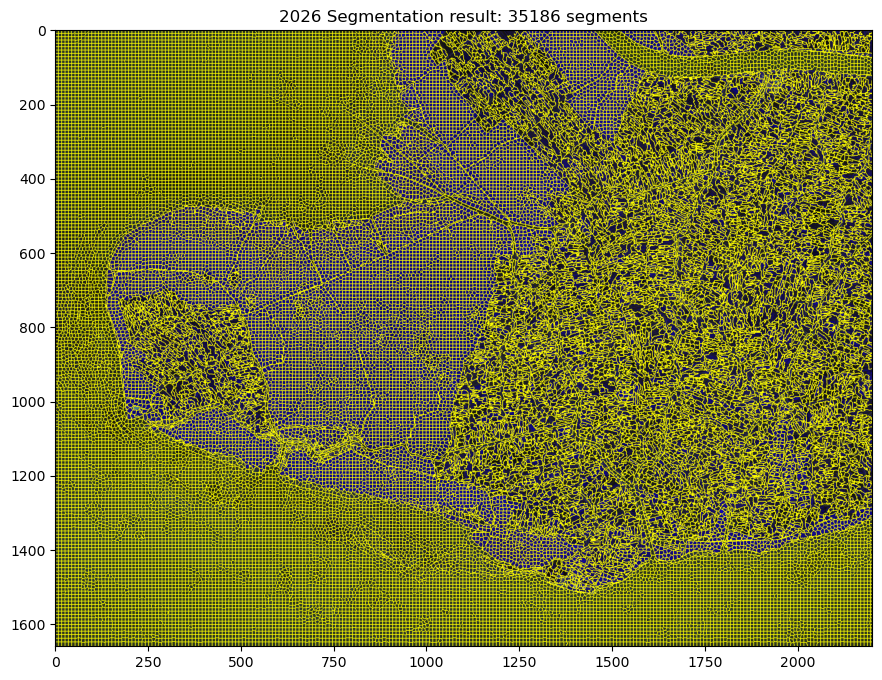

In [7]:
rgb = exposure.rescale_intensity(band_data[:, :, :3].astype(float))
plt.figure(figsize=(12, 8))
plt.imshow(mark_boundaries(rgb, segments2026))
plt.title(f'2026 Segmentation result: {len(np.unique(segments2026))} segments')

In [8]:
# Describing each segment based on spectral properties: 
# spectral properties = variables that will classify each segment as a land cover type.

# Function that returns the min, max, mean, variance, skewness, and kurtois for each band in a given array of pixels.
def segment_features(segment_pixels):
    features = []
    npixels, nbands = segment_pixels.shape
    for b in range(nbands):
        stats = scipy.stats.describe(segment_pixels[:, b])
        band_stats = list(stats.minmax) + list(stats)[2:]
        if npixels == 1:
            # in this case the variance = nan, change it 0.0
            band_stats[3] = 0.0
        features += band_stats
    return features

In [10]:
# Makes a list of segment ID numbers and the pixels for each are passed to segment_features.
# Statistics from segment_features are stored in objects list, and object_id stored in a separate list.
# May take several hours to run, depending on setup. 
#Note from Will- actually didn't take that long to run, maybe 15 mins

segment2026_ids = np.unique(segments2026)
objects2026 = []
object_ids2026 = []
for id in segment2026_ids:
    segment_pixels = img[segments2026 == id]
    object_features = segment_features(segment_pixels)
    objects2026.append(object_features)
    object_ids2026.append(id)

In [17]:
#Create pandas dataframe, set segment ID as index
df_camau_2026 = pd.DataFrame(objects2026)
df_camau_2026["segment_id"] = object_ids2026
df_camau_2026 = df_camau_2026.set_index("segment_id")

In [32]:
#Give column names from stats and bands; number of columns = # stats x # bands
stats = ["min","max","mean","var","skew","kurt"]
bands = ["B03","B04","B08","B11","SCL","NDVI","NDWI","CMRI"]

columns = []
for b in bands:
    for s in stats:
        columns.append(f"{b}_{s}")

df_camau_2026.columns = columns

In [33]:
df_camau_2026

,B03_min,B03_max,B03_mean,B03_var,B03_skew,B03_kurt,B04_min,B04_max,B04_mean,B04_var,...,NDWI_mean,NDWI_var,NDWI_skew,NDWI_kurt,CMRI_min,CMRI_max,CMRI_mean,CMRI_var,CMRI_skew,CMRI_kurt
segment_id,,,,,,,,,,,,,,,,,,,,,
1,-0.131559,-0.120522,-0.125021,0.000006,-1.010380,0.168314,-0.100946,-0.095115,-0.097807,0.000002,...,-0.275068,0.000075,0.378710,-0.631598,-0.577142,-0.525164,-0.546789,0.000179,-0.366495,-0.653786
2,-0.127810,-0.119689,-0.123391,0.000002,-0.180381,0.858892,-0.102196,-0.095323,-0.098205,0.000001,...,-0.275332,0.000067,-0.186350,-0.068422,-0.578386,-0.507676,-0.541639,0.000225,0.013883,-0.182325
3,-0.125311,-0.120105,-0.122612,0.000002,0.022011,-0.765033,-0.100738,-0.095115,-0.098334,0.000002,...,-0.278783,0.000045,0.109852,-0.130844,-0.566351,-0.499596,-0.532704,0.000170,-0.102070,-0.199600
4,-0.126561,-0.120105,-0.122620,0.000002,-0.682486,0.546023,-0.101363,-0.094907,-0.097766,0.000002,...,-0.283219,0.000027,-0.047673,-0.167808,-0.544213,-0.505924,-0.525071,0.000081,-0.088244,-0.594335
5,-0.125520,-0.119480,-0.122734,0.000002,0.055860,-0.533073,-0.100530,-0.094490,-0.097938,0.000001,...,-0.282553,0.000056,-0.201568,-0.474040,-0.555057,-0.491523,-0.526304,0.000191,0.327294,-0.495936
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
35182,-0.131455,-0.111150,-0.123301,0.000025,0.228017,-1.009530,-0.118543,-0.088659,-0.101335,0.000081,...,-0.270762,0.000271,0.127472,-0.766890,-0.602148,-0.485014,-0.543759,0.000936,0.023255,-1.191121
35183,-0.119897,-0.105111,-0.112977,0.000009,0.129281,-0.546960,-0.093553,-0.082152,-0.088701,0.000005,...,-0.261409,0.000232,0.331544,-0.941173,-0.618854,-0.513089,-0.565214,0.000688,-0.290897,-0.980142
35184,-0.121563,-0.111463,-0.116500,0.000004,-0.058925,-0.146353,-0.097614,-0.086160,-0.090762,0.000006,...,-0.275716,0.000255,0.322568,-0.005713,-0.621432,-0.481049,-0.540399,0.000909,-0.302853,-0.071298
